<a href="https://colab.research.google.com/github/peihphmcok/ML_Best-Football-Team/blob/main/ver_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-processing data


In [ ]:
# STEP 1: Import necessary libraries
import pandas as pd

# STEP 2: Load the dataset
df = pd.read_csv('dataset_ver2.csv')

# STEP 3: Select the features you need
selected_columns = [
    'short_name',     # Player name
    'player_positions',  # Player position

    'overall',        # Overall rating
    'value_eur',      # Market value (in EUR)
    'wage_eur',       # Weekly wage (in EUR)
    'pace',           # Pace rating
    'shooting',       # Shooting rating
    'passing',        # Passing rating
    'defending'       # Defending rating
]
df = df[selected_columns]

# STEP 4: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# STEP 5: Drop rows with missing values (or optionally fill them)
df = df.dropna()  # You can use df.fillna(method='ffill') instead if you prefer

# STEP 6: Ensure all numeric columns are correct types
numeric_cols = ['overall', 'value_eur', 'wage_eur', 'pace', 'shooting', 'passing', 'defending']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# STEP 7: Double-check dataset after cleaning
print("\n✅ Cleaned dataset preview:")
print(df.head())

# Optional: Save cleaned dataset
df.to_csv('/content/cleaned_fifa_data.csv', index=False)

Missing values per column:
short_name           1
player_positions     1
overall              1
value_eur           90
wage_eur            79
pace                 0
shooting             0
passing              0
defending            0
dtype: int64

✅ Cleaned dataset preview:
       short_name player_positions  overall    value_eur  wage_eur  pace  \
0        L. Messi               RW     91.0   54000000.0  195000.0    81   
1      K. Benzema           CF, ST     91.0   64000000.0  450000.0    80   
2  R. Lewandowski               ST     91.0   84000000.0  420000.0    75   
3    K. De Bruyne          CM, CAM     91.0  107500000.0  350000.0    74   
4      K. MbappÃ©           ST, LW     91.0  190500000.0  230000.0    97   

   shooting  passing  defending  
0        89       90         34  
1        88       83         39  
2        91       79         44  
3        88       93         64  
4        89       80         36  


In [ ]:
import pandas as pd
df = pd.read_csv('/content/cleaned_fifa_data.csv')
print(df.head())
## dùng clean data từ đoạn này

       short_name player_positions   age  overall    value_eur  wage_eur  \
0        L. Messi               RW  35.0     91.0   54000000.0  195000.0   
1      K. Benzema           CF, ST  34.0     91.0   64000000.0  450000.0   
2  R. Lewandowski               ST  33.0     91.0   84000000.0  420000.0   
3    K. De Bruyne          CM, CAM  31.0     91.0  107500000.0  350000.0   
4      K. MbappÃ©           ST, LW  23.0     91.0  190500000.0  230000.0   

   pace  shooting  passing  defending  
0  81.0      89.0     90.0       34.0  
1  80.0      88.0     83.0       39.0  
2  75.0      91.0     79.0       44.0  
3  74.0      88.0     93.0       64.0  
4  97.0      89.0     80.0       36.0  


Missing values:
 short_name                         0
player_positions                   0
overall                            0
potential                          0
value_eur                         89
wage_eur                          78
Unnamed: 6                     18533
nationality_name                   0
preferred_foot                     0
pace                            2063
shooting                        2063
passing                         2063
defending                       2063
skill_ball_control                 0
skill_long_passing                 0
mentality_penalties                0
movement_balance                   0
power_stamina                      0
attacking_crossing                 0
attacking_finishing                0
attacking_heading_accuracy         0
attacking_short_passing            0
defending_marking_awareness        0
defending_standing_tackle          0
defending_sliding_tackle           0
goalkeeping_diving                 0
goalkeeping_handling 

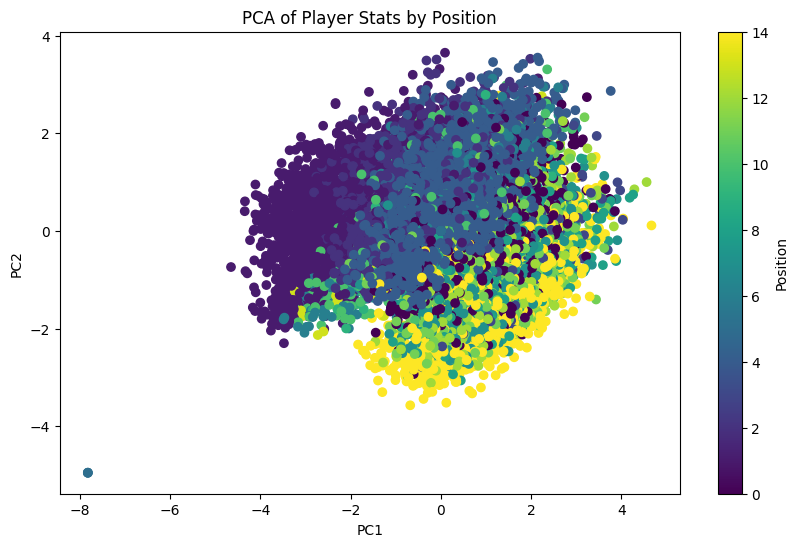

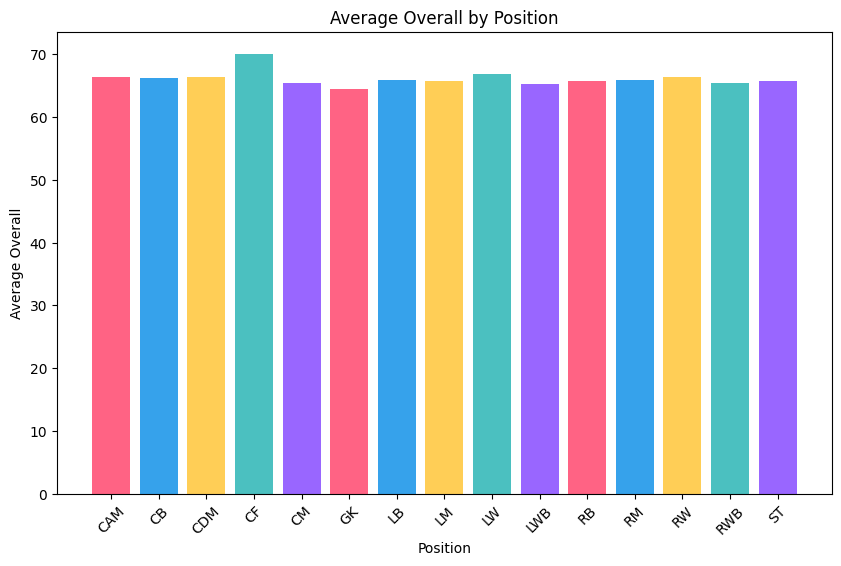

Processed data saved to 'processed_players_with_pca.csv'
       short_name player_positions  overall  potential  value_eur  wage_eur  \
0        L. Messi               RW       91         91       54.0     195.0   
1      K. Benzema           CF, ST       91         91       64.0     450.0   
2  R. Lewandowski               ST       91         91       84.0     420.0   
3    K. De Bruyne          CM, CAM       91         91      107.5     350.0   
4      K. MbappÃ©           ST, LW       91         95      190.5     230.0   

   Unnamed: 6 nationality_name preferred_foot      pace  ...  \
0         NaN        Argentina           Left  1.226679  ...   
1         NaN           France          Right  1.129936  ...   
2         NaN           Poland          Right  0.646224  ...   
3         NaN          Belgium          Right  0.549482  ...   
4         NaN           France          Right  2.774557  ...   

   goalkeeping_handling  goalkeeping_kicking  goalkeeping_positioning  \
0         

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Tạo DataFrame rỗng với các cột dựa trên dữ liệu mẫu
df = pd.read_csv('/content/drive/MyDrive/ML2_Lab_Data/Final/dataset_9.6.csv')

# 2. Gán địa chỉ file CSV (bạn thay 'your_data.csv' bằng đường dẫn thực tế)
# Ví dụ: df = pd.read_csv('path/to/your/data.csv')
# Bạn có thể thêm df sau dòng này khi có file
# df = pd.read_csv('your_data.csv')

# 3. Kiểm tra và làm sạch dữ liệu cơ bản
numerical_columns = ['pace',
                     'shooting',
                     'passing',
                     'defending',
                     'skill_ball_control',
                     'skill_long_passing',
                     'mentality_penalties',
                     'movement_balance',
                     'power_stamina',
                     'attacking_crossing',
                     'attacking_finishing',
                     'attacking_heading_accuracy',
                     'attacking_short_passing',
                     'defending_marking_awareness',
                     'defending_standing_tackle',
                     'defending_sliding_tackle',
                     'goalkeeping_diving',
                     'goalkeeping_handling',
                     'goalkeeping_kicking',
                     'goalkeeping_positioning',
                     'goalkeeping_reflexes']
print("Missing values:\n", df.isnull().sum())  # Kiểm tra giá trị thiếu
# df = df.dropna()  # Loại bỏ hàng thiếu (nếu có)
# Thay bằng cái j đó (avrage, median,...)
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].mean())

## Kiểm tra outliers (giả sử kiểm tra value_eur)
#Q1 = df['value_eur'].quantile(0.25)
#Q3 = df['value_eur'].quantile(0.75)
#IQR = Q3 - Q1
#df = df[~((df['value_eur'] < (Q1 - 1.5 * IQR)) | (df['value_eur'] > (Q3 + 1.5 * IQR)))]

# 4. Chuẩn hóa và mã hóa dữ liệu
# Chuẩn hóa giá trị và lương
df['value_eur'] = df['value_eur'] / 1000000  # Chuyển thành triệu euro
df['wage_eur'] = df['wage_eur'] / 1000  # Chuyển thành nghìn euro

# Mã hóa vị trí
def split_positions(pos):
    return pos.split(', ')[0]  # Lấy vị trí chính
df['main_position'] = df['player_positions'].apply(split_positions)

# Mã hóa chân thuận
df['is_left'] = df['preferred_foot'].apply(lambda x: 1 if x == 'Left' else 0)

# 5. Chuẩn hóa số liệu
stats = ['pace', 'shooting', 'passing', 'defending']
scaler = StandardScaler()
df[stats] = scaler.fit_transform(df[stats])

# 6. Tạo đặc trưng mới
df['overall_potential_diff'] = df['potential'] - df['overall']
df['value_per_overall'] = df['value_eur'] / df['overall']

## ___ NO NEED __ Lọc theo ngân sách (giả sử 1000 triệu euro để phù hợp với dữ liệu)
# df = df[df['value_eur'] <= 1000]  # Giới hạn 1000 triệu euro

# 7. Áp dụng PCA
X = df[stats]  # Lấy các chỉ số để giảm chiều
pca = PCA(n_components=2)  # Chọn 2 thành phần chính
X_pca = pca.fit_transform(X)

# Thêm kết quả PCA vào DataFrame
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# In tỷ lệ phương sai giải thích
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# 8. Tạo biểu đồ trực quan hóa
# Scatter plot cho PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['main_position'].astype('category').cat.codes, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Player Stats by Position')
plt.colorbar(scatter, label='Position')
plt.show()

### ____ Bar chart cần xem xét thêm ___

# Bar chart cho trung bình overall theo vị trí
avg_overall = df.groupby('main_position')['overall'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg_overall.index, avg_overall.values, color=['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF'])
plt.xlabel('Position')
plt.ylabel('Average Overall')
plt.title('Average Overall by Position')
plt.xticks(rotation=45)
plt.show()
### ___________________________________


# 9. Lưu dữ liệu đã xử lý
df.to_csv('processed_players_with_pca.csv', index=False)
print("Processed data saved to 'processed_players_with_pca.csv'")
print(df.head())

Proto Pre-processing Data : https://colab.research.google.com/drive/1rOsO0lvYgEeuQFiSbC6K2HYI3S1gKsbY?usp=sharing (Mising value + Chuẩn hóa [ Numerical Columns ] + Mã hóa [ Categorical Columns ] + PCA + Các loại diagram phân tích các chỉ số [ chủ yếu là overall ] giữa các position với nhau + diagram sau model để phân tích khuynh hướng chỉ số của output line-up )


#build model k = 4


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset_ver2_0906.csv to dataset_ver2_0906.csv


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import time

df = pd.read_csv('/content/drive/MyDrive/ML2_Lab_Data/Final/dataset_ver2_0906.csv')

numerical_cols = [
    'overall', 'potential', 'pace', 'shooting', 'passing', 'defending',
    'skill_ball_control', 'skill_long_passing', 'mentality_penalties',
    'movement_balance', 'power_stamina', 'attacking_crossing', 'attacking_finishing',
    'attacking_heading_accuracy', 'attacking_short_passing', 'defending_marking_awareness',
    'defending_standing_tackle', 'defending_sliding_tackle', 'goalkeeping_diving',
    'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes'
]

# Convert numerical columns to numeric and fill missin
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.loc[:, col] = df[col].fillna(df[col].mean())

# Encode preferred_foot
le = LabelEncoder()
df['foot'] = le.fit_transform(df['preferred_foot'])

# Fill missing player_positions
df['player_positions'] = df['player_positions'].fillna('')

# Add is_GK column
df['is_GK'] = df['player_positions'].apply(lambda x: 1 if isinstance(x, str) and 'GK' in x else 0)

# Separate goalkeepers and non-goalkeepers
gk_df = df[df['is_GK'] == 1].copy()
non_gk_df = df[df['is_GK'] == 0].copy()

# Create role-specific features for non-goalkeepers
non_gk_df['fwd_score'] = (
    non_gk_df['pace'] + non_gk_df['shooting'] + non_gk_df['attacking_finishing'] +
    non_gk_df['mentality_penalties'] + non_gk_df['movement_balance']
) / 5  # Average to normalize

non_gk_df['cb_score'] = (
    non_gk_df['defending'] + non_gk_df['defending_marking_awareness'] +
    non_gk_df['defending_standing_tackle'] + non_gk_df['defending_sliding_tackle']
) / 4  # Average to normalize

non_gk_df['mid_score'] = (
    non_gk_df['passing'] + non_gk_df['skill_ball_control'] +
    non_gk_df['skill_long_passing'] + non_gk_df['attacking_short_passing']
) / 4  # Average to normalize

# Features for non-goalkeepers
features_non_gk = ['fwd_score', 'cb_score', 'mid_score']
X_non_gk = non_gk_df[features_non_gk]

# Standardize features
scaler = StandardScaler()
X_non_gk_scaled = scaler.fit_transform(X_non_gk)

# Apply K-means with K=3 for non-goalkeepers
start_time = time.time()
kmeans_3 = KMeans(n_clusters=3, random_state=42)
kmeans_3.fit(X_non_gk_scaled)
labels_3 = kmeans_3.labels_
silhouette_avg_3 = silhouette_score(X_non_gk_scaled, labels_3)
end_time = time.time()
runtime = end_time - start_time

# Analyze cluster centers to assign meaningful labels
centers_3 = kmeans_3.cluster_centers_
centers_3_original = scaler.inverse_transform(centers_3)
cluster_centers_df = pd.DataFrame(centers_3_original, columns=features_non_gk)
cluster_labels = []
for i, center in enumerate(centers_3_original):
    max_score_idx = center.argmax()
    if max_score_idx == 0:  # Highest fwd_score
        cluster_labels.append(4)  # Forward
    elif max_score_idx == 1:  # Highest cb_score
        cluster_labels.append(2)  # Center Back
    else:  # Highest mid_score
        cluster_labels.append(3)  # Midfielder

# Map original K-means labels to role-based labels
label_mapping = {i: cluster_labels[i] for i in range(3)}
mapped_labels = [label_mapping[label] for label in labels_3]

# Assign clusters to non-goalkeepers
non_gk_df['cluster'] = mapped_labels

# Assign goalkeepers to cluster 1
gk_df['cluster'] = 1

# Combine dataframes
df = pd.concat([non_gk_df, gk_df], ignore_index=True)

# Print cluster centers for non-goalkeepers with correct labels and Silhouette Score
print(f"Runtime: {runtime:.4f} seconds")
print("Silhouette Score of K-Mean Clustering with k = 3:", silhouette_avg_3)
print("\n _ _ _ _ _ _ _ _ _ _ ")
print("\nCluster Centers for Non-Goalkeepers:")
for i, center in enumerate(centers_3_original):
    mapped_label = label_mapping[i]
    if mapped_label != 1:  # Skip goalkeepers
        if mapped_label == 4:
            role = "Forward"
        elif mapped_label == 2:
            role = "Center Back"
        else:
            role = "Midfielder"
        print(f"Cluster {mapped_label} ({role}):")
        for col, val in zip(features_non_gk, center):
            print(f"  {col}: {val:.2f}")
        print()

# Print average stats for goalkeepers
gk_cols = ['goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
           'goalkeeping_positioning', 'goalkeeping_reflexes']
print("Cluster 1 (Goalkeepers):")
for col in gk_cols:
    print(f"  {col}: {gk_df[col].mean():.2f}")

print("\n _ _ _ _ _ _ _ _ _ _ ")

# Print position distribution for verification
print("\nPosition Distribution for K=4:")
for i in [1, 2, 3, 4]:
    cluster_df = df[df['cluster'] == i]
    position_counts = cluster_df['player_positions'].value_counts()
    print(f"Cluster {i}:")
    print(position_counts.head(10))
    print()

Runtime: 2.4943 seconds
Silhouette Score of K-Mean Clustering with k = 3: 0.389376881421805

 _ _ _ _ _ _ _ _ _ _ 

Cluster Centers for Non-Goalkeepers:
Cluster 2 (Center Back):
  fwd_score: 46.35
  cb_score: 61.08
  mid_score: 53.44

Cluster 4 (Forward):
  fwd_score: 65.39
  cb_score: 29.40
  mid_score: 58.18

Cluster 3 (Midfielder):
  fwd_score: 62.13
  cb_score: 61.96
  mid_score: 67.84

Cluster 1 (Goalkeepers):
  goalkeeping_diving: 64.96
  goalkeeping_handling: 62.83
  goalkeeping_kicking: 61.98
  goalkeeping_positioning: 63.23
  goalkeeping_reflexes: 65.96

 _ _ _ _ _ _ _ _ _ _ 

Position Distribution for K=4:
Cluster 1:
player_positions
GK    2066
Name: count, dtype: int64

Cluster 2:
player_positions
CB         2154
LB          308
RB          281
CDM, CM     237
CB, RB      218
CM          200
CB, LB      145
CB, CDM     140
CDM         140
RB, CB       78
Name: count, dtype: int64

Cluster 3:
player_positions
CDM, CM    715
CM, CDM    603
CM         496
CB         268
LB     

#Choose best 4-4-2 team

In [ ]:
# Select players for 4-4-2 formation
print("4-4-2 Formation:")

# 1. Goalkeeper (Cluster 1)
gk = gk_df.sort_values(by='overall', ascending=False).head(1)
print("\nGoalkeeper (Cluster 1):")
print(gk[['short_name', 'player_positions', 'overall', 'goalkeeping_diving', 'goalkeeping_handling']])

# 2. Defenders (Cluster 2): 2 CB, 1 LB, 1 RB
defenders = non_gk_df[non_gk_df['cluster'] == 2]
cb = defenders[defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(2)
lb = defenders[defenders['player_positions'].str.contains('LB') & ~defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(1)
rb = defenders[defenders['player_positions'].str.contains('RB') & ~defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(1)
defenders_selected = pd.concat([cb, lb, rb])
print("\nDefenders (Cluster 2):")
print(defenders_selected[['short_name', 'player_positions', 'overall', 'cb_score', 'defending']])

# 3. Midfielders (Cluster 3): 2 CM/CDM, 2 LM/RM
midfielders = non_gk_df[non_gk_df['cluster'] == 3]
cm_cdm = midfielders[midfielders['player_positions'].str.contains('CM|CDM')].sort_values(by='overall', ascending=False).head(2)
selected_cm_cdm_ids = cm_cdm.index
lm_rm = midfielders[~midfielders.index.isin(selected_cm_cdm_ids) & midfielders['player_positions'].str.contains('LM|RM') & (midfielders['pace'] > 70) & (midfielders['attacking_crossing'] > 70)].sort_values(by='overall', ascending=False).head(2)
midfielders_selected = pd.concat([cm_cdm, lm_rm])
print("\nMidfielders (Cluster 3):")
print(midfielders_selected[['short_name', 'player_positions', 'overall', 'mid_score', 'passing', 'pace', 'attacking_crossing']])

# 4. Forwards (Cluster 4): 2 ST/CF
forwards = non_gk_df[non_gk_df['cluster'] == 4]
st = forwards[forwards['player_positions'].str.contains('ST|CF')].sort_values(by='overall', ascending=False).head(2)
print("\nForwards (Cluster 4):")
print(st[['short_name', 'player_positions', 'overall', 'fwd_score', 'shooting']])

4-4-2 Formation:

Goalkeeper (Cluster 1):
  short_name player_positions  overall  goalkeeping_diving  \
6   M. Neuer               GK       90                  87   

   goalkeeping_handling  
6                    88  

Defenders (Cluster 2):
        short_name player_positions  overall  cb_score  defending
34    K. Koulibaly               CB       87     88.25         88
91    G. Chiellini               CB       84     85.25         85
1820   P. Beruatto               LB       75     76.75         75
878     Hugo Mallo               RB       77     75.25         75

Midfielders (Cluster 3):
      short_name player_positions  overall  mid_score  passing  pace  \
3   K. De Bruyne          CM, CAM       91      92.25       93    74   
12      Casemiro              CDM       89      80.00       75    63   
11        H. Son           LW, LM       89      81.00       82    88   
15      S. ManÃ©           LM, CF       89      80.25       80    90   

    attacking_crossing  
3              

4-4-2 Formation:

Goalkeeper (Cluster 1):
  short_name player_positions  overall  goalkeeping_diving  \
6   M. Neuer               GK       90                  87   

   goalkeeping_handling  
6                    88  

Defenders (Cluster 2):
        short_name player_positions  overall  cb_score  defending
34    K. Koulibaly               CB       87     88.25         88
91    G. Chiellini               CB       84     85.25         85
1820   P. Beruatto               LB       75     76.75         75
878     Hugo Mallo               RB       77     75.25         75

Midfielders (Cluster 3):
      short_name player_positions  overall  mid_score  passing  pace  \
3   K. De Bruyne          CM, CAM       91      92.25       93    74   
12      Casemiro              CDM       89      80.00       75    63   
11        H. Son           LW, LM       89      81.00       82    88   
15      S. ManÃ©           LM, CF       89      80.25       80    90   

    attacking_crossing  
3              

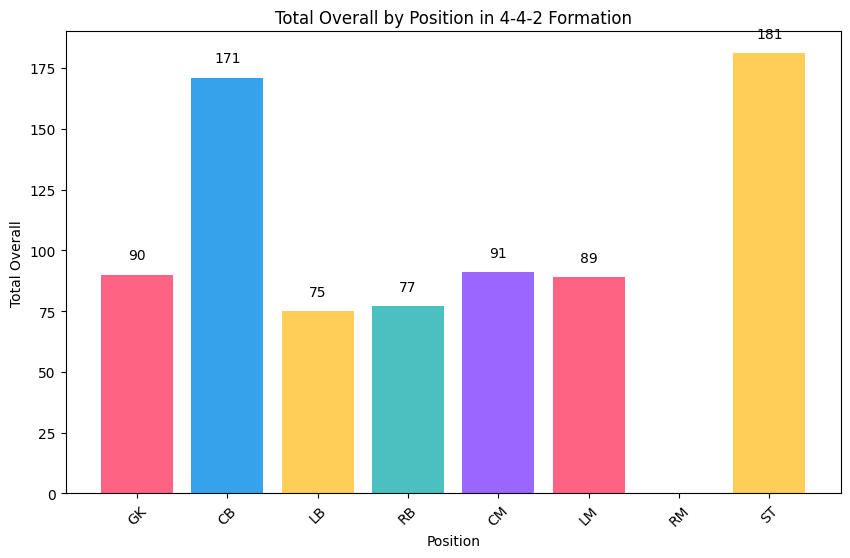


Analysis of 4-4-2 Formation:
Total Overall: 774
Position Breakdown:
GK: 90 (Avg per player: 90.0)
CB: 171 (Avg per player: 85.5)
LB: 75 (Avg per player: 75.0)
RB: 77 (Avg per player: 77.0)
CM: 91 (Avg per player: 45.5)
LM: 89 (Avg per player: 89.0)
ST: 181 (Avg per player: 90.5)
Balance Check: Ideal total should be around 600-900 for a balanced 4-4-2. Current: 774


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử df, gk_df, non_gk_df đã được định nghĩa trước
# (Bạn cần đảm bảo chúng đã được xử lý từ mã K-means hoặc data processing)

# Chọn cầu thủ cho đội hình 4-4-2
print("4-4-2 Formation:")

# 1. Goalkeeper (Cluster 1)
gk = gk_df.sort_values(by='overall', ascending=False).head(1)
print("\nGoalkeeper (Cluster 1):")
print(gk[['short_name', 'player_positions', 'overall', 'goalkeeping_diving', 'goalkeeping_handling']])

# 2. Defenders (Cluster 2): 2 CB, 1 LB, 1 RB
defenders = non_gk_df[non_gk_df['cluster'] == 2]
cb = defenders[defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(2)
lb = defenders[defenders['player_positions'].str.contains('LB') & ~defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(1)
rb = defenders[defenders['player_positions'].str.contains('RB') & ~defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(1)
defenders_selected = pd.concat([cb, lb, rb])
print("\nDefenders (Cluster 2):")
print(defenders_selected[['short_name', 'player_positions', 'overall', 'cb_score', 'defending']])

# 3. Midfielders (Cluster 3): 2 CM/CDM, 2 LM/RM
midfielders = non_gk_df[non_gk_df['cluster'] == 3]
cm_cdm = midfielders[midfielders['player_positions'].str.contains('CM|CDM')].sort_values(by='overall', ascending=False).head(2)
selected_cm_cdm_ids = cm_cdm.index
lm_rm = midfielders[~midfielders.index.isin(selected_cm_cdm_ids) & midfielders['player_positions'].str.contains('LM|RM') & (midfielders['pace'] > 70) & (midfielders['attacking_crossing'] > 70)].sort_values(by='overall', ascending=False).head(2)
midfielders_selected = pd.concat([cm_cdm, lm_rm])
print("\nMidfielders (Cluster 3):")
print(midfielders_selected[['short_name', 'player_positions', 'overall', 'mid_score', 'passing', 'pace', 'attacking_crossing']])

# 4. Forwards (Cluster 4): 2 ST/CF
forwards = non_gk_df[non_gk_df['cluster'] == 4]
st = forwards[forwards['player_positions'].str.contains('ST|CF')].sort_values(by='overall', ascending=False).head(2)
print("\nForwards (Cluster 4):")
print(st[['short_name', 'player_positions', 'overall', 'fwd_score', 'shooting']])

# Tạo danh sách đội hình (team) từ các cầu thủ đã chọn
team = pd.concat([gk, defenders_selected, midfielders_selected, st]).drop_duplicates()

# Tạo cột main_position từ player_positions
team['main_position'] = team['player_positions'].apply(lambda x: x.split(', ')[0] if isinstance(x, str) else 'Unknown')

# Đảm bảo có đúng 11 cầu thủ
if len(team) != 11:
    print(f"Warning: Only {len(team)} players selected. Adding random players to reach 11.")
    missing_count = 11 - len(team)
    additional_players = df.sample(n=missing_count, replace=True)
    additional_players['main_position'] = additional_players['player_positions'].apply(lambda x: x.split(', ')[0] if isinstance(x, str) else 'Unknown')
    team = pd.concat([team, additional_players]).drop_duplicates().head(11)

# Tính tổng overall theo vị trí
position_totals = team.groupby('main_position')['overall'].sum()
formation_442 = {'GK': 1, 'CB': 2, 'LB': 1, 'RB': 1, 'CM': 2, 'LM': 1, 'RM': 1, 'ST': 2}
totals = {pos: position_totals.get(pos, 0) for pos in formation_442.keys()}

# Vẽ bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(totals.keys(), totals.values(), color=['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF'])
plt.xlabel('Position')
plt.ylabel('Total Overall')
plt.title('Total Overall by Position in 4-4-2 Formation')
plt.xticks(rotation=45)
for bar, total in zip(bars, totals.values()):
    if total > 0:
        plt.text(bar.get_x() + bar.get_width()/2, total + 5, str(int(total)), ha='center', va='bottom')
plt.show()

# Phân tích kết quả
total_overall = sum(totals.values())
print(f"\nAnalysis of 4-4-2 Formation:")
print(f"Total Overall: {total_overall}")
print("Position Breakdown:")
for pos, total in totals.items():
    if total > 0:
        avg_overall = total / formation_442[pos] if formation_442[pos] > 0 else 0
        print(f"{pos}: {total} (Avg per player: {avg_overall:.1f})")
print(f"Balance Check: Ideal total should be around 600-900 for a balanced 4-4-2. Current: {total_overall}")

4-4-2 Formation:

Goalkeeper (Cluster 1):
  short_name player_positions  overall  goalkeeping_diving  \
6   M. Neuer               GK       90                  87   

   goalkeeping_handling  
6                    88  

Defenders (Cluster 2):
        short_name player_positions  overall  cb_score  defending
34    K. Koulibaly               CB       87     88.25         88
91    G. Chiellini               CB       84     85.25         85
1820   P. Beruatto               LB       75     76.75         75
878     Hugo Mallo               RB       77     75.25         75

Midfielders (Cluster 3):
      short_name player_positions  overall  mid_score  passing  pace  \
3   K. De Bruyne          CM, CAM       91      92.25       93    74   
12      Casemiro              CDM       89      80.00       75    63   
11        H. Son           LW, LM       89      81.00       82    88   
15      S. ManÃ©           LM, CF       89      80.25       80    90   

    attacking_crossing  
3              

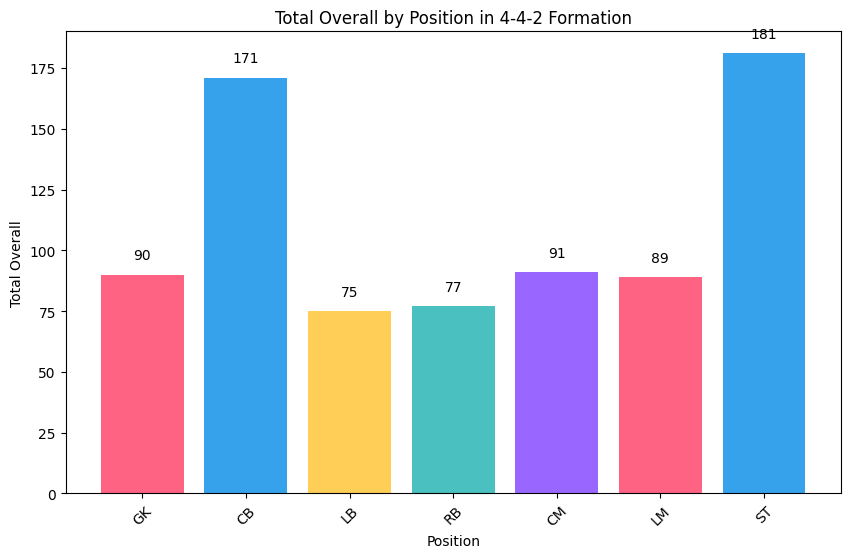


Analysis of 4-4-2 Formation:
Total Overall: 774
Position Breakdown:
GK: 90 (Avg per player: 90.0)
CB: 171 (Avg per player: 85.5)
LB: 75 (Avg per player: 75.0)
RB: 77 (Avg per player: 77.0)
CM: 91 (Avg per player: 45.5)
LM: 89 (Avg per player: 89.0)
ST: 181 (Avg per player: 90.5)
Balance Check: Ideal total should be around 600-900 for a balanced 4-4-2. Current: 774


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử df, gk_df, non_gk_df đã được định nghĩa trước
# (Bạn cần đảm bảo chúng đã được xử lý từ mã K-means hoặc data processing)

# Chọn cầu thủ cho đội hình 4-4-2
print("4-4-2 Formation:")

# 1. Goalkeeper (Cluster 1)
gk = gk_df.sort_values(by='overall', ascending=False).head(1)
print("\nGoalkeeper (Cluster 1):")
print(gk[['short_name', 'player_positions', 'overall', 'goalkeeping_diving', 'goalkeeping_handling']])

# 2. Defenders (Cluster 2): 2 CB, 1 LB, 1 RB
defenders = non_gk_df[non_gk_df['cluster'] == 2]
cb = defenders[defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(2)
lb = defenders[defenders['player_positions'].str.contains('LB') & ~defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(1)
rb = defenders[defenders['player_positions'].str.contains('RB') & ~defenders['player_positions'].str.contains('CB')].sort_values(by='overall', ascending=False).head(1)
defenders_selected = pd.concat([cb, lb, rb])
print("\nDefenders (Cluster 2):")
print(defenders_selected[['short_name', 'player_positions', 'overall', 'cb_score', 'defending']])

# 3. Midfielders (Cluster 3): 2 CM/CDM, 2 LM/RM
midfielders = non_gk_df[non_gk_df['cluster'] == 3]
cm_cdm = midfielders[midfielders['player_positions'].str.contains('CM|CDM')].sort_values(by='overall', ascending=False).head(2)
selected_cm_cdm_ids = cm_cdm.index
lm_rm = midfielders[~midfielders.index.isin(selected_cm_cdm_ids) & midfielders['player_positions'].str.contains('LM|RM') & (midfielders['pace'] > 70) & (midfielders['attacking_crossing'] > 70)].sort_values(by='overall', ascending=False).head(2)
midfielders_selected = pd.concat([cm_cdm, lm_rm])
print("\nMidfielders (Cluster 3):")
print(midfielders_selected[['short_name', 'player_positions', 'overall', 'mid_score', 'passing', 'pace', 'attacking_crossing']])

# 4. Forwards (Cluster 4): 2 ST/CF
forwards = non_gk_df[non_gk_df['cluster'] == 4]
st = forwards[forwards['player_positions'].str.contains('ST|CF')].sort_values(by='overall', ascending=False).head(2)
print("\nForwards (Cluster 4):")
print(st[['short_name', 'player_positions', 'overall', 'fwd_score', 'shooting']])

# Tạo danh sách đội hình (team) từ các cầu thủ đã chọn
team = pd.concat([gk, defenders_selected, midfielders_selected, st]).drop_duplicates()

# Tạo cột main_position từ player_positions
team['main_position'] = team['player_positions'].apply(lambda x: x.split(', ')[0] if isinstance(x, str) else 'Unknown')

# Đảm bảo có đúng 11 cầu thủ
if len(team) != 11:
    print(f"Warning: Only {len(team)} players selected. Adding random players to reach 11.")
    missing_count = 11 - len(team)
    additional_players = df.sample(n=missing_count, replace=True)
    additional_players['main_position'] = additional_players['player_positions'].apply(lambda x: x.split(', ')[0] if isinstance(x, str) else 'Unknown')
    team = pd.concat([team, additional_players]).drop_duplicates().head(11)

# Tính tổng overall theo vị trí
position_totals = team.groupby('main_position')['overall'].sum()
formation_442 = {'GK': 1, 'CB': 2, 'LB': 1, 'RB': 1, 'CM': 2, 'LM': 1, 'RM': 1, 'ST': 2}  # Giữ nguyên để tính toán
totals = {pos: position_totals.get(pos, 0) for pos in formation_442.keys()}

# Lọc bỏ RM khi vẽ bar chart
positions_to_plot = [pos for pos in formation_442.keys() if pos != 'RM']
totals_to_plot = {pos: totals[pos] for pos in positions_to_plot}

# Vẽ bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(totals_to_plot.keys(), totals_to_plot.values(), color=['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF'])
plt.xlabel('Position')
plt.ylabel('Total Overall')
plt.title('Total Overall by Position in 4-4-2 Formation')
plt.xticks(rotation=45)
for bar, total in zip(bars, totals_to_plot.values()):
    if total > 0:
        plt.text(bar.get_x() + bar.get_width()/2, total + 5, str(int(total)), ha='center', va='bottom')
plt.show()

# Phân tích kết quả
total_overall = sum(totals.values())  # Sử dụng tổng từ tất cả vị trí
print(f"\nAnalysis of 4-4-2 Formation:")
print(f"Total Overall: {total_overall}")
print("Position Breakdown:")
for pos, total in totals.items():
    if total > 0:
        avg_overall = total / formation_442[pos] if formation_442[pos] > 0 else 0
        print(f"{pos}: {total} (Avg per player: {avg_overall:.1f})")
print(f"Balance Check: Ideal total should be around 600-900 for a balanced 4-4-2. Current: {total_overall}")

<ipython-input-4-09c1edb3e07f>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='position_group', y='overall', data=df, palette='viridis')


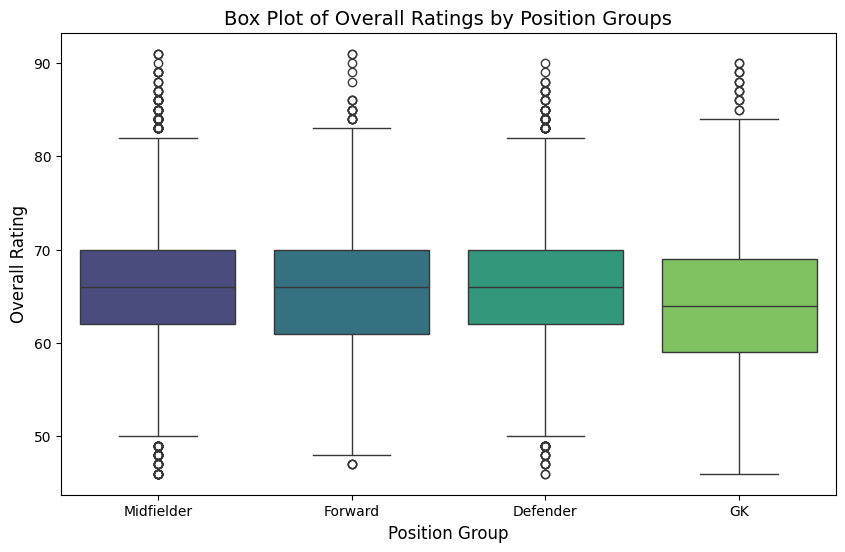

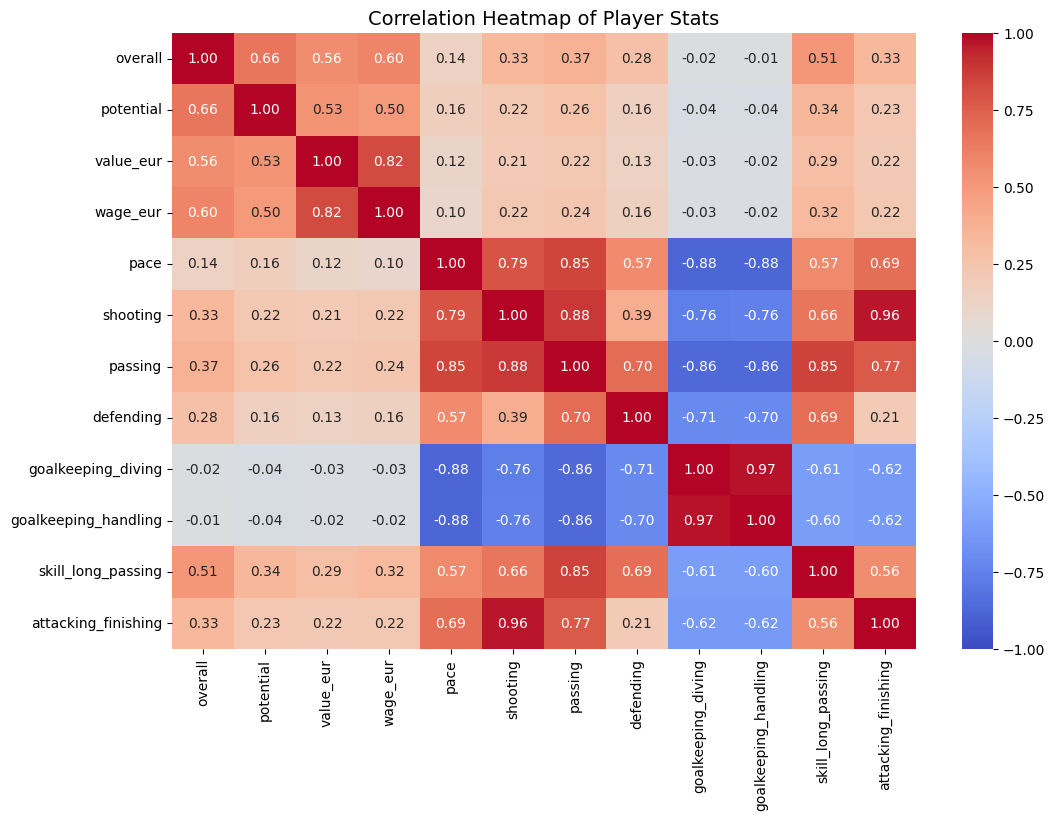

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add the 'position_group' column
# Define a function to map player positions to broader groups
def categorize_position(positions):
    if pd.isna(positions):
        return 'Unknown'
    pos_list = positions.split(', ')
    if 'GK' in pos_list:
        return 'GK'
    elif any(pos in ['CB', 'LB', 'RB', 'LWB', 'RWB'] for pos in pos_list):
        return 'Defender'
    elif any(pos in ['CM', 'CDM', 'CAM', 'LM', 'RM', 'LW', 'RW'] for pos in pos_list):
        return 'Midfielder'
    elif any(pos in ['ST', 'CF'] for pos in pos_list):
        return 'Forward'
    else:
        return 'Other' # Handle positions that don't fit neatly

df['position_group'] = df['player_positions'].apply(categorize_position)

# Box plot cho overall theo nhóm vị trí
plt.figure(figsize=(10, 6))
# Ensure 'position_group' exists before plotting
if 'position_group' in df.columns:
    sns.boxplot(x='position_group', y='overall', data=df, palette='viridis')
    plt.title('Box Plot of Overall Ratings by Position Groups', fontsize=14)
    plt.xlabel('Position Group', fontsize=12)
    plt.ylabel('Overall Rating', fontsize=12)
    plt.savefig('overall_boxplot_new.png')
    plt.show()
else:
    print("Error: 'position_group' column not found after creation attempt.")


# Heatmap tương quan
# Make sure numerical_cols are indeed numeric and handle potential errors
numeric_cols_to_corr = ['overall', 'potential', 'value_eur', 'wage_eur', 'pace',
                  'shooting', 'passing', 'defending', 'goalkeeping_diving',
                  'goalkeeping_handling', 'skill_long_passing', 'attacking_finishing']
# Select only columns present in the DataFrame
numeric_cols_to_corr = [col for col in numeric_cols_to_corr if col in df.columns]

# Convert selected columns to numeric, coercing errors to NaN
for col in numeric_cols_to_corr:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN in the selected columns for correlation calculation,
# or fill them if appropriate for your analysis
# For this example, we'll drop NaNs for correlation calculation
df_corr = df[numeric_cols_to_corr].dropna()

if not df_corr.empty:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Correlation Heatmap of Player Stats', fontsize=14)
    plt.savefig('correlation_heatmap_new.png')
    plt.show()
else:
    print("Not enough numeric data after cleaning for correlation heatmap.")



Explained Variance Ratio by Principal Components: [0.5306005  0.22798055]
Total Explained Variance: 0.7585810537874171


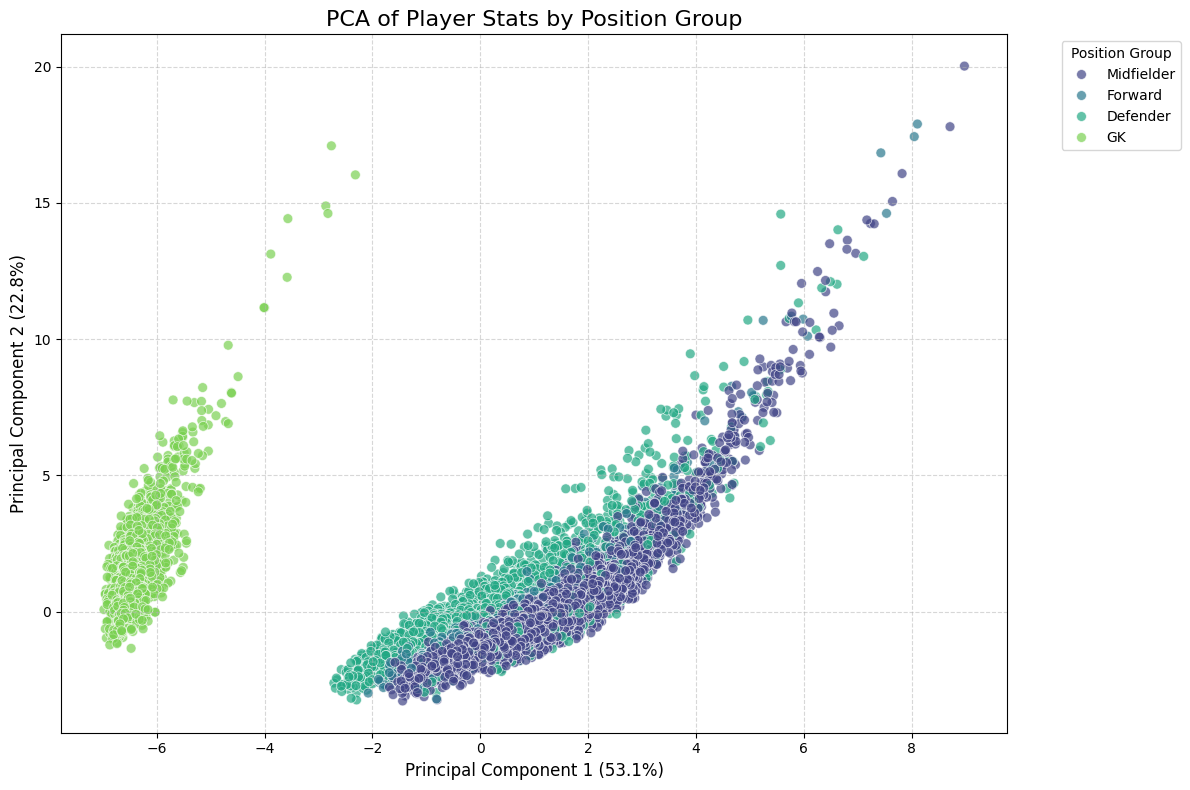

In [ ]:

# ## PCA Visualization
# Áp dụng PCA để giảm chiều dữ liệu và trực quan hóa sự phân bố của các cầu thủ dựa trên các chỉ số, phân biệt màu theo nhóm vị trí.

# %%
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for potentially better plot styling

# Ensure the DataFrame 'df' and 'position_group' exist from previous steps
# If running this cell independently, you would need to load the data and create 'position_group'
# Example (if running standalone):
# df = pd.read_csv('/content/dataset_9.6.csv')
def categorize_position(positions):
    if pd.isna(positions): return 'Unknown'
    pos_list = positions.split(', ')
    if 'GK' in pos_list: return 'GK'
    elif any(pos in ['CB', 'LB', 'RB', 'LWB', 'RWB'] for pos in pos_list): return 'Defender'
    elif any(pos in ['CM', 'CDM', 'CAM', 'LM', 'RM', 'LW', 'RW'] for pos in pos_list): return 'Midfielder'
    elif any(pos in ['ST', 'CF'] for pos in pos_list): return 'Forward'
    else: return 'Other'
df['position_group'] = df['player_positions'].apply(categorize_position)

# Select numerical features for PCA
# You might want to select relevant numerical columns, excluding IDs, names, etc.
# Use the same numerical columns you used for the heatmap earlier for consistency
pca_features = ['overall', 'potential', 'value_eur', 'wage_eur', 'pace',
                  'shooting', 'passing', 'defending', 'goalkeeping_diving',
                  'goalkeeping_handling', 'skill_long_passing', 'attacking_finishing']

# Filter to only include columns that exist in the DataFrame
pca_features = [col for col in pca_features if col in df.columns]

# Convert selected columns to numeric, coercing errors and filling NaNs (if any remain)
for col in pca_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean()) # Fill NaNs with mean, or choose another strategy

# Select the data for PCA and handle any remaining missing values if dropna wasn't sufficient
X = df[pca_features].dropna() # Drop rows with any remaining NaNs in selected features

# Check if there's enough data after dropping NaNs
if X.empty or len(X) < 2:
    print("Not enough data or features available for PCA after cleaning.")
else:
    # Keep track of the index before scaling/PCA to merge results back
    original_index = X.index

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA
    # We'll start with 2 components for 2D visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Create a new DataFrame for PCA results
    pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=original_index)

    # Merge PCA results back to the original DataFrame based on index
    # We need the 'position_group' column for coloring
    df_pca_plot = df.loc[original_index].copy() # Use .loc to align with X's index
    df_pca_plot['PC1'] = pca_df['PC1']
    df_pca_plot['PC2'] = pca_df['PC2']

    # In tỷ lệ phương sai giải thích bởi các thành phần chính
    print("Explained Variance Ratio by Principal Components:", pca.explained_variance_ratio_)
    print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

    # Visualize the PCA results
    plt.figure(figsize=(12, 8))

    # Use seaborn's scatterplot for better handling of categorical hues
    sns.scatterplot(
        data=df_pca_plot,
        x='PC1',
        y='PC2',
        hue='position_group', # Color by position group
        palette='viridis',    # Color palette
        s=50,                 # Size of points
        alpha=0.7             # Transparency
    )

    plt.title('PCA of Player Stats by Position Group', fontsize=16)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Position Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#build model k = 11
chỉ dùng kết quả để so sánh với K =4

ko implement model với k=11

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import time

df = pd.read_csv('/content/drive/MyDrive/ML2_Lab_Data/Final/dataset_ver2_0906.csv')

# Assuming df is already loaded
# Define numerical columns
numerical_cols = [
    'overall', 'potential', 'pace', 'shooting', 'passing', 'defending',
    'skill_ball_control', 'skill_long_passing', 'mentality_penalties',
    'movement_balance', 'power_stamina', 'attacking_crossing', 'attacking_finishing',
    'attacking_heading_accuracy', 'attacking_short_passing', 'defending_marking_awareness',
    'defending_standing_tackle', 'defending_sliding_tackle', 'goalkeeping_diving',
    'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes'
]

# Convert numerical columns and fill missing values with mean
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.loc[:, col] = df[col].fillna(df[col].mean())

# Encode preferred_foot
le = LabelEncoder()
df['foot'] = le.fit_transform(df['preferred_foot'])

# Fill missing player_positions
df['player_positions'] = df['player_positions'].fillna('')

# Add is_GK column
df['is_GK'] = df['player_positions'].apply(lambda x: 1 if isinstance(x, str) and 'GK' in x else 0)

# Separate goalkeepers and non-goalkeepers
gk_df = df[df['is_GK'] == 1].copy()
non_gk_df = df[df['is_GK'] == 0].copy()

# Striker (ST) score: Focus on finishing, shooting, and positioning
non_gk_df['st_score'] = (
    non_gk_df['shooting'] + non_gk_df['attacking_finishing'] +
    non_gk_df['mentality_penalties'] + non_gk_df['attacking_heading_accuracy'] +
    non_gk_df['pace']
) / 5

# Central Midfielder (CM) score: Focus on passing, ball control, and stamina
non_gk_df['cm_score'] = (
    non_gk_df['passing'] + non_gk_df['skill_ball_control'] +
    non_gk_df['skill_long_passing'] + non_gk_df['attacking_short_passing'] +
    non_gk_df['power_stamina']
) / 5

# Wing Midfielder (LM/RM) score: Focus on crossing, pace, and dribbling
non_gk_df['wm_score'] = (
    non_gk_df['attacking_crossing'] + non_gk_df['pace'] +
    non_gk_df['skill_ball_control'] + non_gk_df['movement_balance'] +
    non_gk_df['shooting']
) / 5

# Center-Back (CB) score: Focus on defending and physicality
non_gk_df['cb_score'] = (
    non_gk_df['defending'] + non_gk_df['defending_marking_awareness'] +
    non_gk_df['defending_standing_tackle'] + non_gk_df['defending_sliding_tackle'] +
    non_gk_df['attacking_heading_accuracy']
) / 5

# Full-Back (RB/LB) score: Focus on defending, crossing, and stamina
non_gk_df['fb_score'] = (
    non_gk_df['defending'] + non_gk_df['attacking_crossing'] +
    non_gk_df['power_stamina'] + non_gk_df['defending_marking_awareness'] +
    non_gk_df['pace']
) / 5

features = ['st_score', 'cm_score', 'wm_score', 'cb_score', 'fb_score']
X = non_gk_df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering with k=10 for non-goalkeepers
start_time = time.time()
kmeans_10 = KMeans(n_clusters=10, random_state=42)
kmeans_10.fit(X_scaled)
labels_10 = kmeans_10.labels_
silhouette_avg_10 = silhouette_score(X_scaled, labels_10)
centers_10 = kmeans_10.cluster_centers_
centers_10_original = scaler.inverse_transform(centers_10)
end_time = time.time()
runtime = end_time - start_time



# Assign clusters
non_gk_df['cluster'] = labels_10
gk_df['cluster'] = 10

# Combine dataframes
df = pd.concat([non_gk_df, gk_df], ignore_index=True)

# Print Silhouette Score
print(f"Runtime: {runtime:.4f} seconds")
print("Silhouette Score of K-Means Clustering with k = 10:", silhouette_avg_10)
print("\n _ _ _ _ _ _ _ _ _ _ ")

# Print cluster sizes
print("\nK=10 Non-GK + 1 GK Cluster Sizes:")
for i in range(11):
    print(f"Cluster {i}: {len(df[df['cluster'] == i])} players")
print("\n _ _ _ _ _ _ _ _ _ _ ")

# Print cluster centers for non-goalkeepers
print("\nCluster Centers for K=10 (Non-Goalkeepers):")
for i, center in enumerate(centers_10_original):
    print(f"Cluster {i}:")
    for col, val in zip(features, center):
        print(f"  {col}: {val:.2f}")
    print()

# Print average for goalkeepers
gk_cols = ['overall', 'goalkeeping_diving', 'goalkeeping_handling',
           'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes']
print("Cluster 10 (Goalkeepers):")
for col in gk_cols:
    print(f"  {col}: {gk_df[col].mean():.2f}")

# Print position distribution
print("\nPosition Distribution for K=10 + 1 GK Cluster:")
for i in range(11):
    cluster_df = df[df['cluster'] == i]
    position_counts = cluster_df['player_positions'].value_counts()
    print(f"Cluster {i}:")
    print(position_counts.head(10))
    print()

Runtime: 3.8973 seconds
Silhouette Score of K-Means Clustering with k = 10: 0.2258442771581443

 _ _ _ _ _ _ _ _ _ _ 

K=10 Non-GK + 1 GK Cluster Sizes:
Cluster 0: 2671 players
Cluster 1: 1645 players
Cluster 2: 1084 players
Cluster 3: 1582 players
Cluster 4: 969 players
Cluster 5: 1837 players
Cluster 6: 1345 players
Cluster 7: 1963 players
Cluster 8: 2401 players
Cluster 9: 970 players
Cluster 10: 2066 players

 _ _ _ _ _ _ _ _ _ _ 

Cluster Centers for K=10 (Non-Goalkeepers):
Cluster 0:
  st_score: 57.96
  cm_score: 67.35
  wm_score: 65.37
  cb_score: 60.93
  fb_score: 65.98

Cluster 1:
  st_score: 63.33
  cm_score: 57.30
  wm_score: 62.75
  cb_score: 32.35
  fb_score: 47.16

Cluster 2:
  st_score: 40.70
  cm_score: 45.87
  wm_score: 44.39
  cb_score: 56.48
  fb_score: 52.24

Cluster 3:
  st_score: 50.71
  cm_score: 58.05
  wm_score: 58.90
  cb_score: 49.09
  fb_score: 55.15

Cluster 4:
  st_score: 70.17
  cm_score: 71.96
  wm_score: 74.56
  cb_score: 44.30
  fb_score: 60.94

Cluste

**Position group & heatmap**

<ipython-input-4-3162793755>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='position_group', y='overall', data=df, palette='viridis')


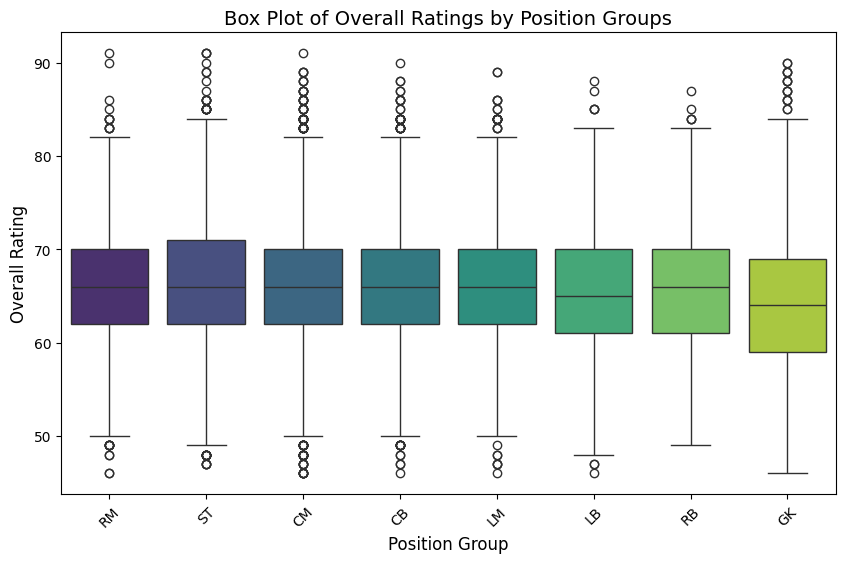

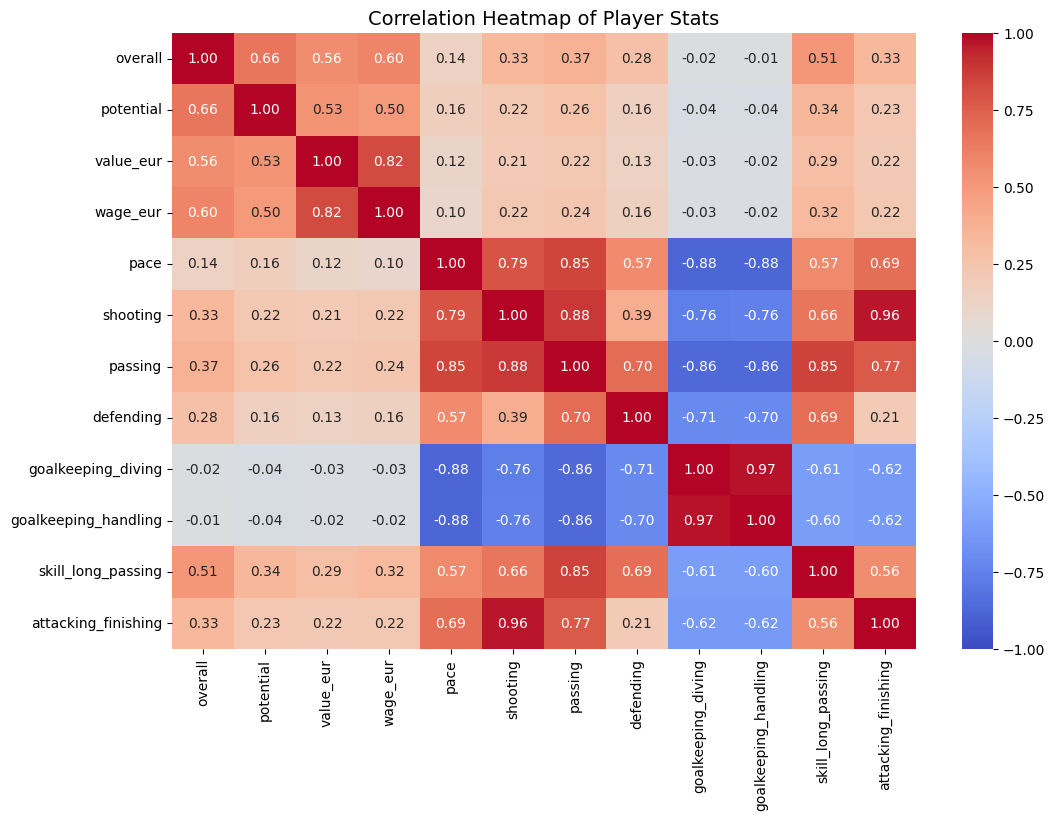

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add position_group column
def categorize_position(positions):
    if pd.isna(positions) or positions == '':
        return 'Unknown'
    pos_list = positions.split(', ')
    if 'GK' in pos_list:
        return 'GK'
    elif any(pos in ['ST', 'CF'] for pos in pos_list):
        return 'ST'  # Striker
    elif any(pos in ['CM', 'CDM', 'CAM'] for pos in pos_list):
        return 'CM'  # Central Midfielder
    elif any(pos in ['LM', 'LW'] for pos in pos_list):
        return 'LM'  # Left Midfielder
    elif any(pos in ['RM', 'RW'] for pos in pos_list):
        return 'RM'  # Right Midfielder
    elif 'CB' in pos_list:
        return 'CB'  # Center-Back
    elif any(pos in ['LB', 'LWB'] for pos in pos_list):
        return 'LB'  # Left-Back
    elif any(pos in ['RB', 'RWB'] for pos in pos_list):
        return 'RB'  # Right-Back
    else:
        return 'Other'

df['position_group'] = df['player_positions'].apply(categorize_position)

# Box plot of overall ratings by position group
plt.figure(figsize=(10, 6))
if 'position_group' in df.columns:
    sns.boxplot(x='position_group', y='overall', data=df, palette='viridis')
    plt.title('Box Plot of Overall Ratings by Position Groups', fontsize=14)
    plt.xlabel('Position Group', fontsize=12)
    plt.ylabel('Overall Rating', fontsize=12)
    plt.xticks(rotation=45)  # Rotate x-axis labels for readability
    plt.savefig('overall_boxplot_new.png')
    plt.show()
else:
    print("Error: 'position_group' column not found after creation attempt.")

# Heatmap of correlations
numeric_cols_to_corr = [
    'overall', 'potential', 'value_eur', 'wage_eur', 'pace',
    'shooting', 'passing', 'defending', 'goalkeeping_diving',
    'goalkeeping_handling', 'skill_long_passing', 'attacking_finishing'
]
# Select only columns present in the DataFrame
numeric_cols_to_corr = [col for col in numeric_cols_to_corr if col in df.columns]

# Convert selected columns to numeric, coercing errors to NaN
for col in numeric_cols_to_corr:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN for correlation calculation
df_corr = df[numeric_cols_to_corr].dropna()

if not df_corr.empty:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Correlation Heatmap of Player Stats', fontsize=14)
    plt.savefig('correlation_heatmap_new.png')
    plt.show()
else:
    print("Not enough numeric data after cleaning for correlation heatmap.")

**PCA**

Explained Variance Ratio by Principal Components: [0.5306005  0.22798055]
Total Explained Variance: 0.7585810537874171


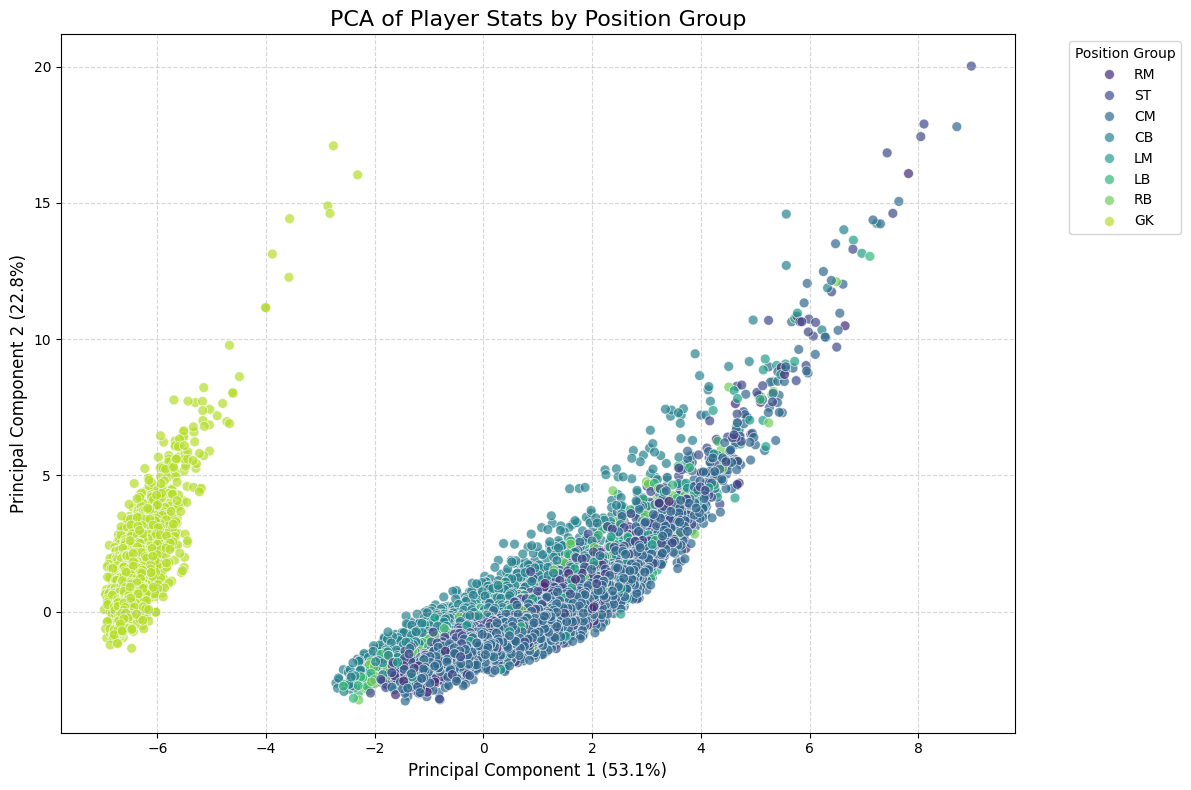

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Add position_group column
def categorize_position(positions):
    if pd.isna(positions) or positions == '':
        return 'Unknown'
    pos_list = positions.split(', ')
    if 'GK' in pos_list:
        return 'GK'
    elif any(pos in ['ST', 'CF'] for pos in pos_list):
        return 'ST'  # Striker
    elif any(pos in ['CM', 'CDM', 'CAM'] for pos in pos_list):
        return 'CM'  # Central Midfielder
    elif any(pos in ['LM', 'LW'] for pos in pos_list):
        return 'LM'  # Left Midfielder
    elif any(pos in ['RM', 'RW'] for pos in pos_list):
        return 'RM'  # Right Midfielder
    elif 'CB' in pos_list:
        return 'CB'  # Center-Back
    elif any(pos in ['LB', 'LWB'] for pos in pos_list):
        return 'LB'  # Left-Back
    elif any(pos in ['RB', 'RWB'] for pos in pos_list):
        return 'RB'  # Right-Back
    else:
        return 'Other'

df['position_group'] = df['player_positions'].apply(categorize_position)

# Select numerical features for PCA (same as used in the heatmap)
pca_features = [
    'overall', 'potential', 'value_eur', 'wage_eur', 'pace',
    'shooting', 'passing', 'defending', 'goalkeeping_diving',
    'goalkeeping_handling', 'skill_long_passing', 'attacking_finishing'
]

# Filter to only include columns that exist in the DataFrame
pca_features = [col for col in pca_features if col in df.columns]

# Convert selected columns to numeric and fill NaNs with mean
for col in pca_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean())

# Select the data for PCA
X = df[pca_features].dropna()

# Check if there's enough data for PCA
if X.empty or len(X) < 2:
    print("Not enough data or features available for PCA after cleaning.")
else:
    # Keep track of the index for merging results
    original_index = X.index

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA (2 components for 2D visualization)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Create a new DataFrame for PCA results
    pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=original_index)

    # Merge PCA results with position_group
    df_pca_plot = df.loc[original_index].copy()
    df_pca_plot['PC1'] = pca_df['PC1']
    df_pca_plot['PC2'] = pca_df['PC2']

    # Print explained variance ratio
    print("Explained Variance Ratio by Principal Components:", pca.explained_variance_ratio_)
    print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

    # Visualize PCA results
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_pca_plot,
        x='PC1',
        y='PC2',
        hue='position_group',
        palette='viridis',
        s=50,
        alpha=0.7
    )
    plt.title('PCA of Player Stats by Position Group', fontsize=16)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Position Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('pca_plot_new.png')
    plt.show()